In [245]:
import os
import numpy as np
import flopy
import math
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import flopy.utils.postprocessing as pp
from flopy.utils import CellBudgetFile, HeadFile

In [ ]:
####################
### set up paths ###
####################

notebook_dir = os.getcwd()
mf6_exe = os.path.join(notebook_dir, "..", "binaries", "MODFLOW6", "windows", "mf6.exe")

workspace = "mf6-com-1"
if not os.path.exists(workspace):
    os.makedirs(workspace)

################################
### random domain generation ###
################################

cell_dim = int(np.random.uniform(1.0, 5.0)) # square cells between 1.0 and 5.0 units
target_lx = int(np.random.uniform(50, 150)) # target domain size between 50-150 units in x
target_ly = int(np.random.uniform(50, 150)) # target domain size between 50-150 units in y

nlay = 1 # number of layers
ncol, nrow = int(target_lx / cell_dim), int(target_ly / cell_dim) # number of columns and rows
lx, ly = float(ncol * cell_dim), float(nrow * cell_dim) # adjust domain size to be an integer number of cells

# calculate cell edges and centers for later use
x_centres = np.linspace(-lx/2 + cell_dim/2, lx/2 - cell_dim/2, ncol)
y_centres = np.linspace(ly/2 - cell_dim/2, -ly/2 + cell_dim/2, nrow)

centre_r = nrow // 2
centre_c = ncol // 2

dt = 7.0 # stress period length in days
nper = 52 # number of stress periods (e.g. 52 weeks in a year)
time_steps = np.arange(dt, (nper * dt) + dt, dt) # time steps for plotting, from dt to nper*dt with step of dt

########################################
### define simulation setup function ###
########################################

def setup_sim(name, wel_data):

    # create the simulation and model objects
    sim = flopy.mf6.MFSimulation(sim_name=name, exe_name=mf6_exe, sim_ws=workspace)
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=[(dt, 1, 1.0)]*nper)
    
    # save_flows=True at the model level needed for ZONEBUDGET
    gwf = flopy.mf6.ModflowGwf(sim, modelname=name, save_flows=True)
    
    flopy.mf6.ModflowGwfdis(gwf, nlay=nlay, nrow=nrow, ncol=ncol, 
                            delr=cell_dim, delc=cell_dim, 
                            xorigin=-lx/2, yorigin=-ly/2)
    
    flopy.mf6.ModflowIms(sim, complexity="SIMPLE")
    
    # save_flows=True at the model level needed for ZONEBUDGET
    flopy.mf6.ModflowGwfnpf(gwf, k=1e-3, icelltype=0, save_flows=True) 
    flopy.mf6.ModflowGwfsto(gwf, ss=1e-5, transient=True, save_flows=True)
    flopy.mf6.ModflowGwfic(gwf, strt=0.0)
    
    # save_flows=True at the model level needed for ZONEBUDGET
    flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_data, save_flows=True)
    
    # added budget_filerecord and "BUDGET" to saverecord
    flopy.mf6.ModflowGwfoc(gwf, 
                            head_filerecord=f"{name}.hds", 
                            budget_filerecord=f"{name}.cbc",
                            saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])
    return sim, gwf

#################################
### compliance zone and wells ###
#################################

# geometry and coordinate snapping logic using a dummy model to access the grid object
_, dummy_gwf = setup_sim("dummy", {})
grid = dummy_gwf.modelgrid
xc, yc = grid.xcellcenters, grid.ycellcenters

# physical parameters for compliance zone and no-go zone
comp_padding = 0.75
nogo_padding = 0.2
comp_hw, comp_hh = (lx / 2) * comp_padding, (ly / 2) * comp_padding
nogo_hw, nogo_hh = comp_hw * nogo_padding, comp_hh * nogo_padding

# get bounding row/column indices
r_min, c_min = grid.intersect(-comp_hw, comp_hh)
r_max, c_max = grid.intersect(comp_hw, -comp_hh)
r_start, r_end = sorted([r_min, r_max])
c_start, c_end = sorted([c_min, c_max])

# generate perimeter CP cells for flux monitoring
cp_cells = []
for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)]) # top/bottom
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)]) # left/right

# generate a centre well
centre_well_x = x_centres[centre_c]
centre_well_y = y_centres[centre_r]

# generate random wells within the compliance zone but outside the no-go zone
# ensure they are snapped to cell centres and not duplicated
n_wells = 3 
wells = []

while len(wells) < n_wells:
    wx, wy = np.random.uniform(-lx/2, lx/2), np.random.uniform(-ly/2, ly/2)
    
    # check if inside the compliance zone
    is_in_compliance = (-comp_hw < wx < comp_hw) and (-comp_hh < wy < comp_hh)
    
    # check if outside the no-go zone
    is_in_nogo = (-nogo_hw < wx < nogo_hw) and (-nogo_hh < wy < nogo_hh)
    
    if is_in_compliance and not is_in_nogo:
        r, c = grid.intersect(wx, wy)
        if (r, c) not in [(w['r'], w['c']) for w in wells]:
            wells.append({
                'r': r, 
                'c': c, 
                'Q': np.random.uniform(0.001, 1, nper)
            })

################
### analysis ###
################

# run the random well scenario
# generates the average drawdown at the compliance points per stress period for the random pumping scenario at the wells

wel_spd_r = {p: [((0, w['r'], w['c']), -w['Q'][p]) for w in wells] for p in range(nper)}
sim_r, _ = setup_sim("random_target", wel_spd_r)
sim_r.write_simulation()
sim_r.run_simulation(silent=True)

hds_r = flopy.utils.binaryfile.HeadFile(os.path.join(workspace, "random_target.hds")).get_alldata()
s_target = [np.mean([0.0 - hds_r[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)]
s_incremental_target = np.diff(s_target, prepend=0)

# run the unit response (Q = 1 at centre well) scenario 
# generates the drawdown at the compliance points per unit pumping at the centre well

wel_spd_u = {p: [((0, centre_r, centre_c), -1)] for p in range(nper)} 
sim_u, _ = setup_sim("unit_response", wel_spd_u)
sim_u.write_simulation()
sim_u.run_simulation(silent=True)

hds_u = flopy.utils.binaryfile.HeadFile(os.path.join(workspace, "unit_response.hds")).get_alldata()
U = np.array([np.mean([0.0 - hds_u[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)])

# conduct deconvolution
# finds the equivalent pumping rate time series at the centre well 
# to match the target drawdown at the compliance points
q_equiv = np.zeros(nper)
delta_q = np.zeros(nper)

for k in range(nper):
    # prev_impact is the drawdown caused at time k by all previous changes (delta_q)
    prev_impact = sum(delta_q[j] * U[k-j] for j in range(k))
    # required change in Q to meet the cumulative target drawdown at time k, accounting for previous impacts
    # divide by U[0] since it's the immediate response to a change in Q 
    delta_q[k] = (s_target[k] - prev_impact) / U[0] 
    q_equiv[k] = np.sum(delta_q[:k+1])

# write and run the equivalent pumping scenario at the centre well
wel_spd_val = {p: [((0, centre_r, centre_c), -abs(q_equiv[p]))] for p in range(nper)}

# initialize and run the validation model
sim_val, _ = setup_sim("validation_run", wel_spd_val)
sim_val.write_simulation()
sim_val.run_simulation(silent=True)

# load the results from the validation HDS file
hds_val = flopy.utils.binaryfile.HeadFile(
    os.path.join(workspace, "validation_run.hds")
).get_alldata()

# calculate resulting CUMULATIVE drawdown at the compliance points
s_val = [np.mean([0.0 - hds_val[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)]

# calculate INCREMENTAL drawdown
s_incremental_val = np.diff(s_val, prepend=0)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model random_target...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package ic...
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 3 based on size of stress_period_data
    writing package oc...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model unit_response...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package ic...
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
writing simulation...
  writing simulation name file...
  writing simulation tdi

In [273]:
#####################
### visualisation ###
#####################

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                    subplot_titles=("Weekly Drawdown at Compliance Ring", "Weekly Pumping Rates"))

# row 1: drawdown at compliance points - target vs equivalent centre well match
fig.add_trace(go.Scatter(x=time_steps, y=s_incremental_target, name=f"Superposition of {n_wells} Random Wells Drawdown (Target)", 
                         line=dict(color='green', width=4)), row=1, col=1)
fig.add_trace(go.Scatter(x=time_steps, y=s_incremental_val, name="Equivalent Centre Well (Match)", 
                         line=dict(color='red', dash='dot', width=2)), row=1, col=1)

# row 2: pumping rates of the random wells and the equivalent centre well
for i, w in enumerate(wells):
    fig.add_trace(go.Scatter(x=time_steps, y=w['Q'], name=f"Well {i+1}", 
                             line=dict(width=1), opacity=0.4), row=2, col=1)

fig.add_trace(go.Scatter(x=time_steps, y=q_equiv, name="Centre Well Pumping Rate", 
                         line=dict(color='black', width=3)), row=2, col=1)

fig.update_layout(height=800, template="plotly_white", 
                  title=(f"Multi-Well Numerical Analysis: {n_wells} Individual Wells vs Equivalent Centre Well Responses"))
fig.update_yaxes(title_text="Drawdown (m)", row=1, col=1)
fig.update_yaxes(title_text="Pumping Rate (m³/d)", row=2, col=1)

fig.show()

In [276]:
# generate grid lines for plotting
x_edges = np.linspace(-lx/2, lx/2, ncol + 1)
y_edges = np.linspace(-ly/2, ly/2, nrow + 1)

grid_x, grid_y = [], []
for x in x_edges:
    grid_x.extend([float(x), float(x), None])
    grid_y.extend([float(y_edges[0]), float(y_edges[-1]), None])
for y in y_edges:
    grid_x.extend([float(x_edges[0]), float(x_edges[-1]), None])
    grid_y.extend([float(y), float(y), None])

fig = go.Figure()

# plot domain boundary
fig.add_shape(type="rect", x0=-lx/2, y0=-ly/2, x1=lx/2, y1=ly/2, 
              line=dict(color="black"), opacity=0.1)

# plot boundary conditions
fig.add_shape(
    type="rect", x0=-lx/2, y0=-ly/2, x1=lx/2, y1=ly/2,
    line=dict(color="black", width=3),
    fillcolor="rgba(0,0,0,0)",
)

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='black', width=3),
    name="No-Flow Boundary"
))

# plot grid lines
fig.add_trace(go.Scatter(x=grid_x, y=grid_y, mode='lines', 
                         line=dict(color='silver', width=0.5), 
                         name=f"MODFLOW Grid ({nrow}x{ncol})", hoverinfo='skip'))

# plot compliance cells
cp_x = [xc[r, c] for r, c in cp_cells]
cp_y = [yc[r, c] for r, c in cp_cells]
fig.add_trace(go.Scatter(
    x=cp_x, y=cp_y, mode='markers',
    marker=dict(color='yellow', size=5, symbol='square', line=dict(width=1, color='black')),
    name="Compliance Cell"
))

# plot the no-go zone
fig.add_shape(
    type="rect", x0=-nogo_hw, y0=-nogo_hh, x1=nogo_hw, y1=nogo_hh,
    line=dict(color="red", width=2, dash='dash'),
    fillcolor="rgba(255,0,0,0.1)",
    name="No-Go Zone"
)

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name="No-Go Zone"
))

# plot the centre well
fig.add_trace(go.Scatter(
    x=[centre_well_x], y=[centre_well_y], mode='markers+text', 
    text=["Centre Well"], textposition="top center",
    marker=dict(color='black', size=12, symbol='hexagon'), 
    name="Centre Well"
))

# plot the random wells
colours = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']
for i, w in enumerate(wells):
    color = colours[i % len(colours)]
    fig.add_trace(go.Scatter(
        x=[xc[w['r'], w['c']]], y=[yc[w['r'], w['c']]], mode='markers+text', 
        text=[f"W{i+1}"], textposition="top center",
        marker=dict(color=color, size=10, line=dict(width=1, color='white')), 
        name=f"Well {i+1}"
    ))

# pretty up the layout
plot_limit = max(lx, ly) / 2 + 5
fig.update_layout(
    title=f"Multi-Well Numerical Analysis: {n_wells} Individual Wells and a Centre Well in a {nrow}x{ncol} MODFLOW Grid",
    xaxis=dict(title="X Coordinate (m)", range=[-plot_limit, plot_limit], tickformat=".1f"),
    yaxis=dict(title="Y Coordinate (m)", range=[-plot_limit, plot_limit], tickformat=".1f",
               scaleanchor="x", scaleratio=1),
    template="plotly_white", width=800, height=800,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02)
)

fig.show()

In [ ]:
###################
### zone budget ###
###################

zbud_path = os.path.join(notebook_dir, "..", "binaries", "MODFLOW6", "windows", "zbud6.exe")

# initilize the zone arrays for both the random well scenario and the validation scenario
zon = np.ones((1, nrow, ncol), dtype=np.int32) # start with all cells in Zone 1 (far field)

# define the core zone as Zone 3
zon[0, r_start:r_end+1, c_start:c_end+1] = 3

# define the border cells as Zone 2
for r, c in cp_cells:
    zon[0, r, c] = 2

# update the zone array
zb_r = model_r.output.zonebudget(zon)
zb_val = model_val.output.zonebudget(zon)

# write the zone budget input files and run the zone budget utility for both scenarios
for zb_obj in [zb_r, zb_val]:
    zb_obj.write_input()
    
    success, buff = zb_obj.run_model(exe_name=zbud_path, silent=False)
    
    if not success:
        print(f"ZoneBudget failed to run. Check the listing file in {zb_obj.model_ws}")
        # print the buffer to see why it failed (e.g., missing budget files)
        for line in buff:
            print(line)

# extract the dataframes for the random well scenario and the validation scenario
df_r = zb_r.get_dataframes()
df_val = zb_val.get_dataframes()

FloPy is using the following executable to run the model: ..\..\binaries\MODFLOW6\windows\zbud6.exe
                              ZONEBUDGET Version 6
                             U.S. GEOLOGICAL SURVEY
                            VERSION 6.7.0 02/05/2026
.............................................................................................................................................................
 
Normal Termination
FloPy is using the following executable to run the model: ..\..\binaries\MODFLOW6\windows\zbud6.exe
                              ZONEBUDGET Version 6
                             U.S. GEOLOGICAL SURVEY
                            VERSION 6.7.0 02/05/2026
.............................................................................................................................................................
 
Normal Termination


C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_13652\4285026662.py:17: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "wo" (-> color='w'). The keyword argument will take precedence.



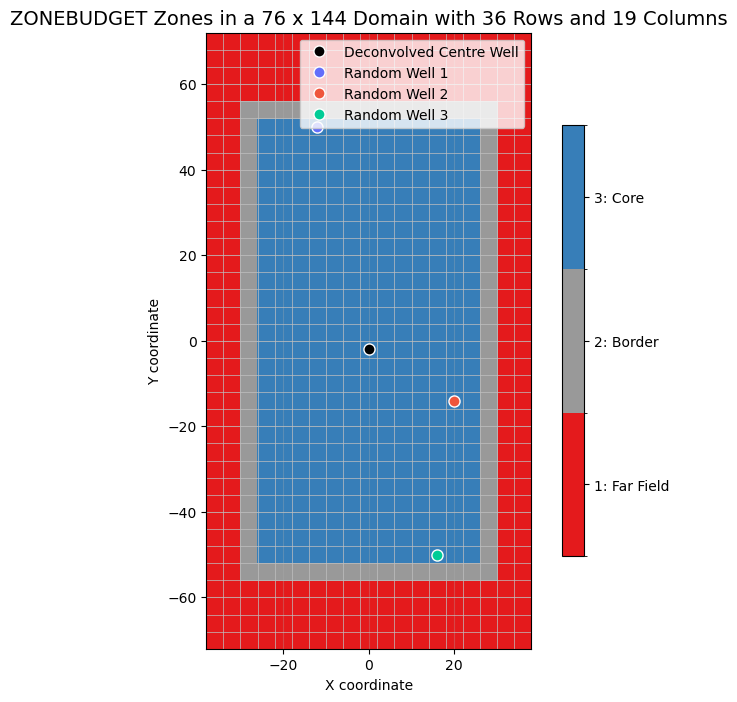

In [280]:
##################################
### visualize ZONEBUDGET zones ###
##################################

cmap = mcolors.ListedColormap(["#e41a1c", "#999999", "#377eb8"])
norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 8))

# Use extent to map the [nrow, ncol] array to the [-lx/2, lx/2] space
# Note: MODFLOW rows go top-to-bottom, so we flip the y-extent or the array
im = ax.imshow(zon[0], 
               extent=[grid.extent[0], grid.extent[1], grid.extent[2], grid.extent[3]], 
               cmap=cmap, norm=norm, origin='upper', interpolation='nearest')

# plot the centre well
ax.plot(centre_well_x, centre_well_y, 'wo', markersize=8, markeredgecolor='white', color='black', label='Deconvolved Centre Well', zorder=5)

# plot the random wells
colours = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']
for i, w in enumerate(wells):
    color = colours[i % len(colours)]
    ax.plot(xc[w['r'], w['c']], yc[w['r'], w['c']], 'o', markersize=8, markeredgecolor='white', color=color, label=f"Random Well {i+1}", zorder=5  
    )

# plot model grid lines
for x in x_edges:
    ax.axvline(x=x, color='silver', linewidth=0.5)
for y in y_edges:
    ax.axhline(y=y, color='silver', linewidth=0.5)

# Add grid and labels
ax.set_title(f"ZONEBUDGET Zones in a {int(lx)} x {int(ly)} Domain with {nrow} Rows and {ncol} Columns", fontsize=14)
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.grid(True, alpha=0.3)

# Discrete colorbar
cbar = plt.colorbar(im, ticks=[1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels(['1: Far Field', '2: Border', '3: Core'])

plt.legend()
plt.show()


In [267]:
##################################
### extract ZONEBUDGET results ###
##################################

# flatten for easier searching
df_r_flat = df_r.reset_index()
df_val_flat = df_val.reset_index()

# extract the fluxes from Zone 2 to Zone 3 for both the random well scenario and the validation scenario
flux_r = df_r_flat[df_r_flat['name'] == 'FROM_ZONE_2']['ZONE_3'].values
flux_val = df_val_flat[df_val_flat['name'] == 'FROM_ZONE_2']['ZONE_3'].values

# prints all non-zero components of the Zone 2 budget as a QC check
z2_budget = df_r_flat[df_r_flat['ZONE_2'] != 0][['name', 'ZONE_2']]
print(z2_budget.groupby('name').sum())

                ZONE_2
name                  
FROM_ZONE_1  27.961898
STO_SS_IN     8.770776
STO_SS_OUT    0.036292
TO_ZONE_3    36.696384


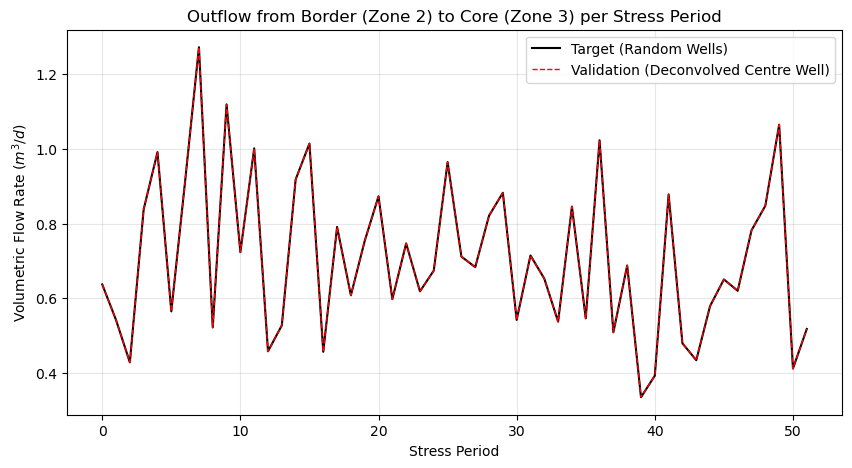

Total Flux (Target): 36.7
Total Flux (Val):    36.7


In [ ]:
####################################
### visualize ZONEBUDGET results ###
####################################

plt.figure(figsize=(10, 5))
plt.plot(flux_r, 'k-', label='Target (Random Wells)')
plt.plot(flux_val, 'r--', label='Validation (Deconvolved Centre Well)', linewidth=1)
plt.title('Outflow from Border (Zone 2) to Core (Zone 3) per Stress Period')
plt.ylabel('Volumetric Flow Rate ($m^3/d$)')
plt.xlabel('Stress Period')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total Flux (Target): {flux_r.sum():.1f}")
print(f"Total Flux (Val):    {flux_val.sum():.1f}")